In [8]:
!pip install sentence-transformers seaborn matplotlib

In [9]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match",
    "The bowler delivered a fast yorker to take a wicket",
    "India won the cricket match by six wickets",
    "The captain set an aggressive field placement",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking a cake requires precise measurements",
    "Spices enhance the flavor of any dish",

    # Cybersecurity (3)
    "Strong passwords help protect against cyber attacks",
    "Encryption ensures data privacy and security",
    "Firewalls prevent unauthorized access to networks"
]

In [11]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [12]:
embeddings = model.encode(sentences)

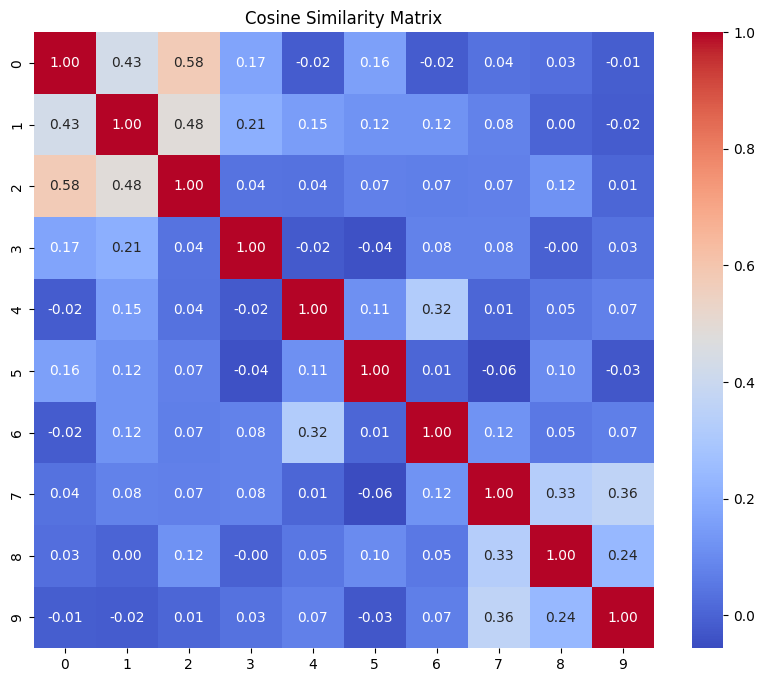

In [13]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

In [14]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

# Top 2 matches
top_indices = scores.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for i in top_indices:
    print(f"Sentence: {sentences[i]}")
    print(f"Similarity Score: {scores[i]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: India won the cricket match by six wickets
Similarity Score: 0.7031

Sentence: The bowler delivered a fast yorker to take a wicket
Similarity Score: 0.6655

